In [1]:
# 1. 导入包 + 中文字体
import os
import re
import numpy as np
import pandas as pd

from linearmodels.panel import PanelOLS

import matplotlib as mpl
import matplotlib.pyplot as plt

# ========== 路径：改成你自己的 ==========
amr_path = r"C:\Users\lunch\Downloads\amr_rate.csv"
x_path   = r"C:\Users\lunch\Downloads\climate_social_eco.csv"

out_dir = r"FE_OUTPUT"
os.makedirs(out_dir, exist_ok=True)

# ========== 中文字体（你已验证 YaHei 可用就保留）==========
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False


In [2]:
# 2. 读取数据 + 统一主键列名（Province/Year）
amr = pd.read_csv(amr_path, encoding="utf-8-sig")
x   = pd.read_csv(x_path,   encoding="utf-8-sig")

# 统一列名：把可能出现的“省份/Province”“YEAR/Year”等都归一
def normalize_key_cols(df):
    col_map = {}
    for c in df.columns:
        cc = c.strip()
        if cc.lower() in ["province", "prov", "省份"]:
            col_map[c] = "Province"
        if cc.lower() in ["year", "yr", "年份", "year "]:
            col_map[c] = "Year"
    return df.rename(columns=col_map)

amr = normalize_key_cols(amr)
x   = normalize_key_cols(x)

assert "Province" in amr.columns and "Year" in amr.columns, "AMR表缺 Province/Year"
assert "Province" in x.columns   and "Year" in x.columns,   "X表缺 Province/Year"

amr["Province"] = amr["Province"].astype(str).str.strip()
x["Province"]   = x["Province"].astype(str).str.strip()
amr["Year"]     = pd.to_numeric(amr["Year"], errors="coerce").astype("Int64")
x["Year"]       = pd.to_numeric(x["Year"], errors="coerce").astype("Int64")

# 只保留 2014-2023（如果你确实是这个跨度）
amr = amr[amr["Year"].between(2014, 2023)]
x   = x[x["Year"].between(2014, 2023)]

print(amr.shape, x.shape)
print(amr[["Province","Year"]].dropna().drop_duplicates().shape,
      x[["Province","Year"]].dropna().drop_duplicates().shape)


(313, 15) (310, 31)
(313, 2) (310, 2)


In [3]:
# 3. 合并面板（Province-Year）
df = amr.merge(x, on=["Province","Year"], how="inner", suffixes=("", "_X"))
df = df.dropna(subset=["Province","Year"]).copy()
df["Year"] = df["Year"].astype(int)
print("Merged:", df.shape)
print("Years:", df["Year"].min(), df["Year"].max())
print("Provinces:", df["Province"].nunique())

Merged: (310, 44)
Years: 2014 2023
Provinces: 31


In [4]:
# 4. 定义要用的 9 个 X
# 你希望的9个变量（用“关键词”去找真实列名）
want = {
    "TA":    ["气温", "平均气温", "TA"],
    "PA":    ["降水", "降水量", "PA", "Rainfall"],
    "R1xday":["R1xday"],
    "PM25":  ["PM2.5", "PM25", "PM_2.5"],
    "MED":   ["医疗水平", "每万人卫生技术人员", "Health", "CHE"],
    "GDP":   ["GDP"],
    "WATER": ["城市用水普及率", "drinking-water", "WASH", "用水"],
    "WASTE": ["生活垃圾无害化处理率", "垃圾处理", "waste"],
    "AMC":   ["抗菌药物使用强度", "Antibiotic use", "antimicrobial", "抗菌药物"]
}

def pick_col(df, keywords):
    cols = list(df.columns)
    # 完全匹配优先
    for k in keywords:
        if k in cols:
            return k
    # 模糊匹配
    for k in keywords:
        pat = re.compile(re.escape(k), re.IGNORECASE)
        hits = [c for c in cols if pat.search(str(c))]
        if len(hits) == 1:
            return hits[0]
        if len(hits) > 1:
            # 取最短的那个（通常更“主”）
            hits = sorted(hits, key=lambda s: len(str(s)))
            return hits[0]
    return None

selected_map = {k: pick_col(df, v) for k, v in want.items()}
print("Selected X mapping:")
for k, c in selected_map.items():
    print(f"  {k:6s} -> {c}")

X_cols = [c for c in selected_map.values() if c is not None]
print("\nX_cols used:", X_cols)

# 关键：如果有 None，说明没匹配到，需要你把 want 里关键词改成你表里的实际列名
missing = [k for k,v in selected_map.items() if v is None]
if missing:
    raise ValueError(f"这些X没在表里匹配到：{missing}。请改 want 的关键词或直接填真实列名。")


Selected X mapping:
  TA     -> 省平均气温
  PA     -> 省平均降水
  R1xday -> R1xday
  PM25   -> PM2.5
  MED    -> 医疗水平
  GDP    -> GDP
  WATER  -> 城市用水普及率
  WASTE  -> 生活垃圾无害化处理率
  AMC    -> 抗菌药物使用强度

X_cols used: ['省平均气温', '省平均降水', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']


In [5]:
# 5. 把 X 与 AMR 相关列转为数值 + 空值处理
# 13个AMR列：你之前找到的是这些（如有增减按需改）
amr_cols = [c for c in df.columns if c in [
    "MRCNS","VREFS","VREFM","PRSP","ERSP","3GCRKP","MRSA","3GCREC","CREC","QREC","CRPA","CRKP","CRAB"
]]
print("AMR cols found:", amr_cols)

# 转数值
for c in X_cols + amr_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 空值处理策略（推荐）：
# 1) 省内（Province）中位数填补；2) 全局中位数再补；3) 仍为空就保留，回归前 dropna
for c in X_cols:
    df[c] = df.groupby("Province")[c].transform(lambda s: s.fillna(s.median()))
    df[c] = df[c].fillna(df[c].median())

# AMR列不强行填补（避免“造数据”），用于构造 AMR_AGG_z 时会自动处理缺失


AMR cols found: ['MRCNS', 'VREFS', 'VREFM', 'PRSP', 'ERSP', '3GCRKP', 'MRSA', '3GCREC', 'CREC', 'QREC', 'CRPA', 'CRKP', 'CRAB']


In [6]:
# 6. 构造 AMR_AGG_z
def zscore_series(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    mu = s.mean(skipna=True)
    sd = s.std(skipna=True, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return s*0.0
    return (s - mu) / sd

if "AMR_AGG_z" not in df.columns:
    if len(amr_cols) == 0:
        raise ValueError("没找到AMR列，无法构造 AMR_AGG_z。请检查 amr_cols。")
    Z = pd.DataFrame({c: zscore_series(df[c]) for c in amr_cols})
    df["AMR_AGG_z"] = Z.mean(axis=1, skipna=True)
    print("Created AMR_AGG_z")
else:
    df["AMR_AGG_z"] = pd.to_numeric(df["AMR_AGG_z"], errors="coerce")

print(df["AMR_AGG_z"].describe())


Created AMR_AGG_z
count    307.000000
mean      -0.000093
std        0.592088
min       -1.375048
25%       -0.384427
50%       -0.139798
75%        0.353142
max        1.676874
Name: AMR_AGG_z, dtype: float64


In [7]:
# 7. X 全部做 z-score 标准化
def zscore_col(df, c):
    s = pd.to_numeric(df[c], errors="coerce")
    mu = s.mean(skipna=True)
    sd = s.std(skipna=True, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return pd.Series(np.zeros(len(df)), index=df.index)
    return (s - mu) / sd

XZ_cols = []
df2 = df.copy()
for c in X_cols:
    cz = f"{c}_z"
    df2[cz] = zscore_col(df2, c)
    XZ_cols.append(cz)

print("XZ_cols:", XZ_cols)


XZ_cols: ['省平均气温_z', '省平均降水_z', 'R1xday_z', 'PM2.5_z', '医疗水平_z', 'GDP_z', '城市用水普及率_z', '生活垃圾无害化处理率_z', '抗菌药物使用强度_z']


In [8]:
# 8. 固定效应回归（原方案：双固定效应；当前默认：仅年份FE，省份聚类稳健SE）
# 设置面板索引
panel = df2.set_index(["Province", "Year"]).sort_index()

y = panel["AMR_AGG_z"]
X = panel[XZ_cols]

# 回归前：只在需要列上dropna（避免过度删样本）
data = pd.concat([y, X], axis=1).dropna()
y2 = data["AMR_AGG_z"]
X2 = data[XZ_cols]

# 原来这里使用的是 entity_effects=True, time_effects=True 的双固定效应设定
# 当前默认改为仅年份固定效应；如果需要恢复双固定效应，只要把下面两个开关改回 True / True
ENTITY_EFFECTS = False
TIME_EFFECTS = True

# PanelOLS：通过这两个开关控制是否纳入省份/年份固定效应
mod = PanelOLS(y2, X2, entity_effects=ENTITY_EFFECTS, time_effects=TIME_EFFECTS)

# 省份聚类稳健SE
res = mod.fit(cov_type="clustered", cluster_entity=True)

print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              AMR_AGG_z   R-squared:                        0.3841
Estimator:                   PanelOLS   R-squared (Between):              0.4914
No. Observations:                 307   R-squared (Within):              -0.7833
Date:                Tue, Apr 14 2026   R-squared (Overall):              0.1263
Time:                        02:06:38   Log-likelihood                   -164.83
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      19.956
Entities:                          31   P-value                           0.0000
Avg Obs:                       9.9032   Distribution:                   F(9,288)
Min Obs:                       7.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             5.9639
                            

In [9]:
# 9. 导出“Lancet 风格表”
def p_stars(p):
    if p is None or (isinstance(p, float) and (np.isnan(p) or not np.isfinite(p))):
        return ""
    try:
        p = float(p)
    except Exception:
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def fmt_p(p):
    try:
        p = float(p)
    except Exception:
        return ""
    if p < 0.0001:
        return "<0.0001"
    return f"{p:.4f}"

def fmt_coef(b, stars=""):
    # 参考 Lancet 表：系数可保留 3~4 位（你也可以改成 3 位）
    try:
        b = float(b)
    except Exception:
        return ""
    return f"{b:.4f}{stars}"

def fmt_ci(lo, hi):
    try:
        lo = float(lo); hi = float(hi)
    except Exception:
        return ""
    return f"({lo:.4f}, {hi:.4f})"

# 提取结果（只做X，不含截距）
params = res.params.copy()
pvals  = res.pvalues.copy()

ci = res.conf_int()
# 不依赖列名，直接取前两列
ci_lo = ci.iloc[:, 0]
ci_hi = ci.iloc[:, 1]

rows = []
for v in XZ_cols:
    if v not in params.index:
        # 极少数情况下变量被吸收/丢弃会不在index里
        continue
    b = params.loc[v]
    p = pvals.loc[v] if v in pvals.index else np.nan
    lo = ci_lo.loc[v] if v in ci_lo.index else np.nan
    hi = ci_hi.loc[v] if v in ci_hi.index else np.nan

    st = p_stars(p)
    rows.append({
        "Predictor": v.replace("_z",""),
        "Coefficient": fmt_coef(b, st),
        "95% CI": fmt_ci(lo, hi),
        "p value": fmt_p(p)
    })

table = pd.DataFrame(rows)

# 追加 FE/Year 行（跟随上面的模型开关）
table = pd.concat([table, pd.DataFrame([
    {"Predictor":"Province", "Coefficient":"Yes" if ENTITY_EFFECTS else "No", "95% CI":"", "p value":""},
    {"Predictor":"Year",     "Coefficient":"Yes" if TIME_EFFECTS else "No", "95% CI":"", "p value":""},
    {"Predictor":"N (observations)",       "Coefficient":f"{int(res.nobs)}", "95% CI":"", "p value":""},
    {"Predictor":"R-squared (within)",     "Coefficient":f"{res.rsquared_within:.3f}", "95% CI":"", "p value":""},
])], ignore_index=True)

# 保存
csv_path  = os.path.join(out_dir, "AMR_AGG_z_FE_table.csv")
xlsx_path = os.path.join(out_dir, "AMR_AGG_z_FE_table.xlsx")
table.to_csv(csv_path, index=False, encoding="utf-8-sig")
table.to_excel(xlsx_path, index=False)

print("Saved:", csv_path)
print("Saved:", xlsx_path)

table


Saved: FE_OUTPUT\AMR_AGG_z_FE_table.csv
Saved: FE_OUTPUT\AMR_AGG_z_FE_table.xlsx


,Predictor,Coefficient,95% CI,p value
0,省平均气温,0.0725,"(-0.1661, 0.3112)",0.5502
1,省平均降水,-0.1104,"(-0.4027, 0.1819)",0.4578
2,R1xday,0.1049,"(-0.0412, 0.2511)",0.1588
3,PM2.5,0.0823,"(-0.0662, 0.2307)",0.2764
4,医疗水平,0.1789,"(-0.0489, 0.4066)",0.1233
5,GDP,0.1870*,"(0.0258, 0.3481)",0.0231
6,城市用水普及率,-0.0673,"(-0.2351, 0.1005)",0.4308
7,生活垃圾无害化处理率,0.0403,"(-0.0240, 0.1046)",0.2184
8,抗菌药物使用强度,0.1159**,"(0.0324, 0.1993)",0.0067
9,Province,No,,


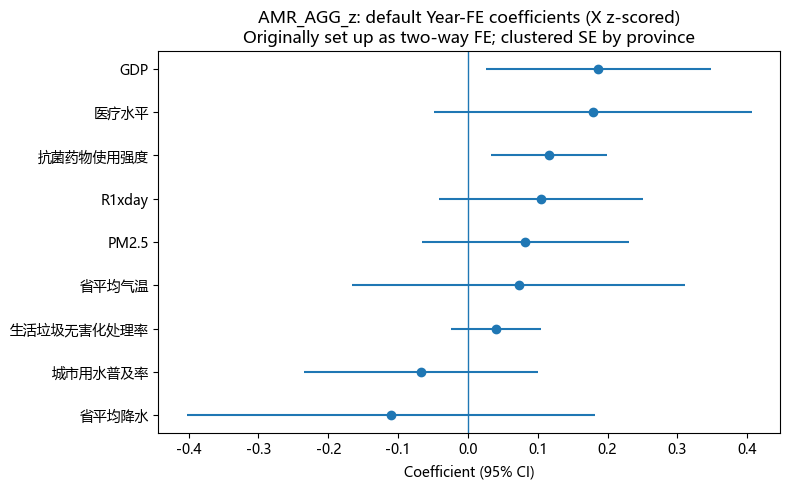

Saved: FE_OUTPUT\AMR_AGG_z_FE_coefplot.png


In [10]:
# 10. 画回归系数图
# 只画X的系数（数值，不含星号字符串）
coef = res.params.reindex(XZ_cols)
ci = res.conf_int().reindex(XZ_cols)
lo = ci.iloc[:,0]
hi = ci.iloc[:,1]

plot_df = pd.DataFrame({
    "Predictor": [c.replace("_z","") for c in XZ_cols],
    "coef": coef.values,
    "lo": lo.values,
    "hi": hi.values,
    "p": res.pvalues.reindex(XZ_cols).values
}).sort_values("coef")

plt.figure(figsize=(8, 5))
ypos = np.arange(len(plot_df))
plt.hlines(y=ypos, xmin=plot_df["lo"], xmax=plot_df["hi"])
plt.plot(plot_df["coef"], ypos, "o")
plt.yticks(ypos, plot_df["Predictor"])
plt.axvline(0, linewidth=1)
plt.title("AMR_AGG_z: default Year-FE coefficients (X z-scored)\nOriginally set up as two-way FE; clustered SE by province")
plt.xlabel("Coefficient (95% CI)")
plt.tight_layout()

fig_path = os.path.join(out_dir, "AMR_AGG_z_FE_coefplot.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print("Saved:", fig_path)
